In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,mean_absolute_error

In [6]:
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=365, freq='D')
data=[]

for store in range(1,6):
  for product in range(1,11):
    base_demand = np.random.randint(20, 50)
    for i,date in enumerate(dates):
      seasonality = np.sin(2 * np.pi * i / 30)
      demand = max(0,int(base_demand + seasonality + np.random.normal(0, 5)))
      data.append([date,store,product,demand])
df =pd.DataFrame(data,columns=["date", "store_id", "product_id" ,"sales"])
df.head()


,date,store_id,product_id,sales
0,2023-01-01,1,1,23
1,2023-01-02,1,1,28
2,2023-01-03,1,1,28
3,2023-01-04,1,1,33
4,2023-01-05,1,1,22


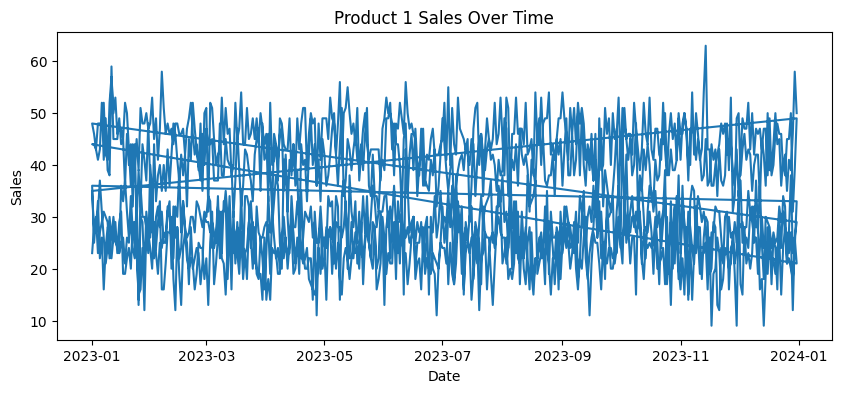

In [11]:
sample = df[df["product_id"]==1]
plt.figure(figsize=(10,4))
plt.plot(sample["date"],sample["sales"])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Product 1 Sales Over Time")
plt.show()

In [15]:
# Feature Engineering

df["day_of_week"]  = df["date"].dt.day_of_week
df["sales_lag_7"]  = df.groupby(["store_id", "product_id"])["sales"].shift(7)
df["sales_lag-14"] = df.groupby(["store_id", "product_id"]) ["sales"].shift(14)
df = df.dropna()

In [16]:
df.head()

,date,store_id,product_id,sales,day_of_week,sales_lag_7,sales_lag-14
14,2023-01-15,1,1,23,6,24.0,23.0
15,2023-01-16,1,1,25,0,28.0,28.0
16,2023-01-17,1,1,26,1,22.0,28.0
17,2023-01-18,1,1,21,2,27.0,33.0
18,2023-01-19,1,1,26,3,25.0,22.0


In [14]:
df.head(100)

,date,store_id,product_id,sales,day_of_week,sales_lag_7,sales_lag-14
0,2023-01-01,1,1,23,6,NaN,NaN
1,2023-01-02,1,1,28,0,NaN,NaN
2,2023-01-03,1,1,28,1,NaN,NaN
3,2023-01-04,1,1,33,2,NaN,NaN
4,2023-01-05,1,1,22,3,NaN,NaN
...,...,...,...,...,...,...,...
95,2023-04-06,1,1,22,3,26.0,29.0
96,2023-04-07,1,1,24,4,28.0,33.0
97,2023-04-08,1,1,20,5,29.0,27.0
98,2023-04-09,1,1,25,6,28.0,26.0


# Step 6


In [20]:
features =["day_of_week","sales_lag_7","sales_lag-14"]
X = df[features]
y = df["sales"]
X_train,y_train,X_test,y_test= train_test_split(X,y,test_size =0.2)

# Model Development

In [27]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))

MAE: 5.309956400640623


# Forecast Future Demand

In [29]:
future = X_test.iloc[:10]
forecast= model.predict(future)
print("Forecast:", forecast)

Forecast: [25.41833333 44.97122783 22.29433333 31.50364544 38.6642619  35.3572381
 21.44530159 28.04269084 39.11802381 39.67078968]


# Feature Importance

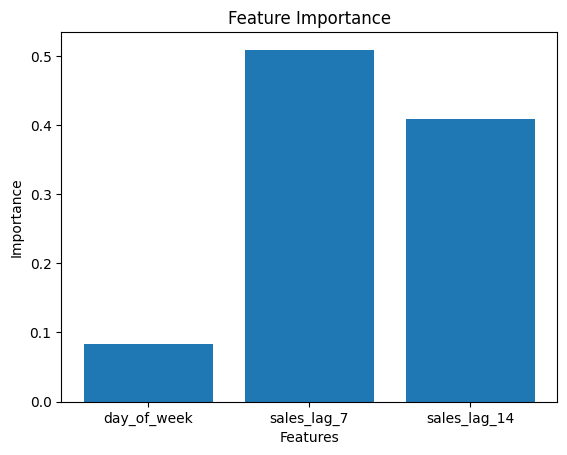

In [31]:
importance = model.feature_importances_
plt.bar(features,importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()